# Agglomerative Clustering — Attrition Clustering

## Agglomerative Clustering Implementation (From Scratch)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix as cm_func, silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

In [35]:
class AgglomerativeClusteringScratch:
  def __init__(self, n_clusters=None, linkage='average'):
    self.n_clusters = n_clusters

    if linkage == 'complete':
      self.linkage_distance_func = self.max_linkage_distance
    elif linkage == 'single':
      self.linkage_distance_func = self.min_linkage_distance
    elif linkage == 'average':
      self.linkage_distance_func = self.avg_linkage_distance
    elif linkage == 'ward':
      self.linkage_distance_func = self.ward_method_distance

  def avg_linkage_distance(self, cluster_A, cluster_B):
    # Compute average linkage distance between two clusters
    distance = 0
    for i in range(cluster_A.shape[0]):
      distance += np.linalg.norm(cluster_B - cluster_A[i, :], axis=1).sum()
    distance /= (cluster_A.shape[0] * cluster_B.shape[0])
    return distance

  def max_linkage_distance(self, cluster_A, cluster_B):
    # Compute maximum linkage distance between two clusters
    distance = 0
    for i in range(cluster_A.shape[0]):
      distance = np.append(np.linalg.norm(cluster_B - cluster_A[i, :], axis=1), distance).max()
    return distance

  def min_linkage_distance(self, cluster_A, cluster_B):
    # Compute minimum linkage distance between two clusters
    distance = np.inf
    for i in range(cluster_A.shape[0]):
      distance = np.append(np.linalg.norm(cluster_B - cluster_A[i, :], axis=1), distance).min()
    return distance

  def ward_method_distance(self, cluster_A, cluster_B):
    # Compute ward linkage distance between two clusters
    n_A = cluster_A.shape[0]
    n_B = cluster_B.shape[0]

    centroid_A = np.mean(cluster_A, axis=0)
    centroid_B = np.mean(cluster_B, axis=0)

    # Distance is proportional to the squared Euclidean distance between centroids
    # scaled by size of the clusters
    diff = centroid_A - centroid_B
    distance = (n_A * n_B) / (n_A + n_B) * np.dot(diff, diff)

    return distance

  def pairwise_distance(self, data, n_samples):
    # Compute the pairwise distance matrix in euclidean distance
    distance_mat = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
      for j in range(i + 1, n_samples):
        distance = np.linalg.norm(data[i] - data[j])
        distance_mat[i, j] = distance
        distance_mat[j, i] = distance
    return distance_mat

  def update(self, data, distance_mat, labels):
      #"Find closest clusters, merge clusters, delete cluster, update distance"
      idx_upper = np.triu_indices(distance_mat.shape[0], k=1)  # Index of upper part of distance matrix (skip diagonal)
      min_value = np.min(distance_mat[idx_upper])  # Value of idx_upper
      row, col = np.argwhere(distance_mat == min_value)[0]  # Index of min_value (same as d_kl)

      # Update label
      labels[labels == col] = row
      labels[labels > col] -= 1

      # Deleted the row and column 'col'
      distance_mat = np.delete(distance_mat, col, 0)
      distance_mat = np.delete(distance_mat, col, 1)

      # Update distance matrix
      for i in range(len(distance_mat)):
          distance_mat[row, i] = self.linkage_distance_func(data[labels == row], data[labels == i])
          distance_mat[i, row] = distance_mat[row, i]
      return distance_mat, labels

  def fit_predict(self, X):
    self.data = X
    self.n_samples = self.data.shape[0]
    self.initial_distance = self.pairwise_distance(self.data, self.n_samples)
    self.labels = np.arange(self.n_samples)
    self.distance_matrix = self.initial_distance.copy()
    while len(np.unique(self.labels)) > self.n_clusters:
      # Fill in the diagonal as infinity to determine that the distance is the same position.
      np.fill_diagonal(self.distance_matrix, np.inf)
      self.distance_matrix, self.labels = self.update(self.data, self.distance_matrix, self.labels)

    return self.labels

## Load & Prepare Data

In [36]:
df = pd.read_csv('../data/processed_data.csv')
print("Dataset shape:", df.shape)

# Separate features and Attrition label
attrition_raw = df['Attrition'].values
attrition_binary = (attrition_raw == attrition_raw.max()).astype(int)  # 1 = Yes, 0 = No
X_full = df.drop(columns=['Attrition']).values
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"Full dataset shape: {X_full.shape}")
print(f"Attrition distribution (real): No={np.sum(attrition_binary == 0)}, Yes={np.sum(attrition_binary == 1)}")

# Sample the dataset for agglomerative clustering (O(n^3) is too slow on full data)
# Stratified sample to preserve the real class imbalance
SAMPLE_SIZE = 1000
np.random.seed(42)
idx_no  = np.where(attrition_binary == 0)[0]
idx_yes = np.where(attrition_binary == 1)[0]
ratio   = len(idx_no) / len(attrition_binary)
n_no    = int(SAMPLE_SIZE * ratio)
n_yes   = SAMPLE_SIZE - n_no
sample_idx = np.concatenate([
    np.random.choice(idx_no,  n_no,  replace=False),
    np.random.choice(idx_yes, n_yes, replace=False)
])
np.random.shuffle(sample_idx)
X      = X_full[sample_idx]
y_true = attrition_binary[sample_idx]

print(f"\nStratified sample of {SAMPLE_SIZE} points (real distribution)")
print(f"Sample attrition distribution: No={np.sum(y_true == 0)}, Yes={np.sum(y_true == 1)}")


Dataset shape: (1470, 37)
Full dataset shape: (1470, 36)
Attrition distribution (real): No=1232, Yes=238

Stratified sample of 1000 points (real distribution)
Sample attrition distribution: No=838, Yes=162


## Run Clustering

In [37]:
print("Running Agglomerative Clustering (ward linkage, K=2)...")

agg = AgglomerativeClusteringScratch(n_clusters=2, linkage='ward')
labels = agg.fit_predict(X)

print(f"\nClustering complete!")
print(f"Cluster distribution:")
for k in np.unique(labels):
    count = np.sum(labels == k)
    print(f"  Cluster {k}: {count} samples ({count/len(labels)*100:.1f}%)")

Running Agglomerative Clustering (ward linkage, K=2)...

Clustering complete!
Cluster distribution:
  Cluster 0: 694 samples (69.4%)
  Cluster 1: 306 samples (30.6%)


## Evaluation on Test Set

In [38]:
def map_clusters_to_labels(cluster_labels, true_labels):
    unique_clusters = np.unique(cluster_labels)
    mapping_1 = cluster_labels.copy()
    acc_1 = np.mean(mapping_1 == true_labels)
    mapping_2 = 1 - cluster_labels
    acc_2 = np.mean(mapping_2 == true_labels)
    if acc_2 > acc_1:
        return mapping_2, acc_2
    return mapping_1, acc_1

predicted, accuracy = map_clusters_to_labels(labels, y_true)

# Confusion Matrix
tp = np.sum((predicted == 1) & (y_true == 1))
tn = np.sum((predicted == 0) & (y_true == 0))
fp = np.sum((predicted == 1) & (y_true == 0))
fn = np.sum((predicted == 0) & (y_true == 1))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0  
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# Clustering quality metrics
sil_score = silhouette_score(X, labels)
db_score = davies_bouldin_score(X, labels)

# Precision, Sensitivity, Specificity, True Negative Rate, F1-score
print("=" * 50)
print("  Agglomerative Clustering — Evaluation Results")
print("=" * 50)
print(f"  Accuracy:           {accuracy:.4f}")
print(f"  Precision:          {precision:.4f}")
print(f"  Recall:             {recall:.4f}")
print(f"  Specificity:        {specificity:.4f}")
print(f"  F1 Score:           {f1:.4f}")
print(f"  Silhouette Score:   {sil_score:.4f}")
print(f"  Davies-Bouldin Idx: {db_score:.4f}")
print(f"\n  Confusion Matrix:")
print(f"                Predicted")
print(f"                No(0)  Yes(1)")
print(f"  Actual No(0)  {tn:<6} {fp}")
print(f"  Actual Yes(1) {fn:<6} {tp}")

print(f"\n  Attrition Rate per Cluster (before mapping):")
for k in np.unique(labels):
    cluster_mask = labels == k
    attrition_rate = np.mean(y_true[cluster_mask]) * 100
    print(f"    Cluster {k}: {attrition_rate:.1f}% attrition "
          f"({np.sum(y_true[cluster_mask])}/{np.sum(cluster_mask)} employees)")

  Agglomerative Clustering — Evaluation Results
  Accuracy:           0.6960
  Precision:          0.2680
  Recall:             0.5062
  Specificity:        0.7327
  F1 Score:           0.3504
  Silhouette Score:   0.0502
  Davies-Bouldin Idx: 3.4697

  Confusion Matrix:
                Predicted
                No(0)  Yes(1)
  Actual No(0)  614    224
  Actual Yes(1) 80     82

  Attrition Rate per Cluster (before mapping):
    Cluster 0: 11.5% attrition (80/694 employees)
    Cluster 1: 26.8% attrition (82/306 employees)


## Confusion Matrix

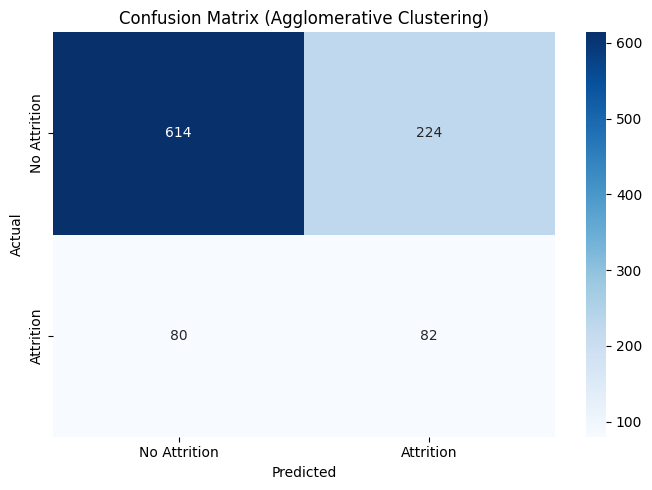

In [39]:
cm_agg = cm_func(y_true, predicted)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_agg, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (Agglomerative Clustering)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Comparing Linkage Methods

In [40]:
# Try different linkage methods and compare
print("Comparing Linkage Methods (K=2):\n")
print(f"{'Linkage':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Silhouette':<12} {'Davies-Bouldin':<14}")
print("-" * 86)

for linkage in ['single', 'complete', 'average', 'ward']:
    agg_temp = AgglomerativeClusteringScratch(n_clusters=2, linkage=linkage)
    temp_labels = agg_temp.fit_predict(X)
    temp_pred, temp_acc = map_clusters_to_labels(temp_labels, y_true)

    tp_t = np.sum((temp_pred == 1) & (y_true == 1))
    fp_t = np.sum((temp_pred == 1) & (y_true == 0))
    fn_t = np.sum((temp_pred == 0) & (y_true == 1))
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0

    n_unique = len(np.unique(temp_labels))
    if n_unique > 1:
        sil_t = silhouette_score(X, temp_labels)
        db_t = davies_bouldin_score(X, temp_labels)
    else:
        sil_t = float('nan')
        db_t = float('nan')

    print(f"{linkage:<12} {temp_acc:<12.4f} {prec_t:<12.4f} {rec_t:<12.4f} {f1_t:<12.4f} {sil_t:<12.4f} {db_t:<14.4f}")

Comparing Linkage Methods (K=2):

Linkage      Accuracy     Precision    Recall       F1-Score     Silhouette   Davies-Bouldin
--------------------------------------------------------------------------------------
single       0.8370       0.0000       0.0000       0.0000       0.2247       0.6401        
complete     0.5350       0.1485       0.3951       0.2159       0.0498       4.0290        
average      0.8360       0.0000       0.0000       0.0000       0.1570       1.5661        
ward         0.6960       0.2680       0.5062       0.3504       0.0502       3.4697        


---
# Sklearn Agglomerative Clustering — Comparison

In [41]:
sklearn_agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
sklearn_labels = sklearn_agg.fit_predict(X)
sklearn_pred, sklearn_acc = map_clusters_to_labels(sklearn_labels, y_true)

tp_sk = np.sum((sklearn_pred == 1) & (y_true == 1))
tn_sk = np.sum((sklearn_pred == 0) & (y_true == 0))
fp_sk = np.sum((sklearn_pred == 1) & (y_true == 0))
fn_sk = np.sum((sklearn_pred == 0) & (y_true == 1))
prec_sk = tp_sk / (tp_sk + fp_sk) if (tp_sk + fp_sk) > 0 else 0
rec_sk = tp_sk / (tp_sk + fn_sk) if (tp_sk + fn_sk) > 0 else 0
spec_sk = tn_sk / (tn_sk + fp_sk) if (tn_sk + fp_sk) > 0 else 0
f1_sk = 2 * prec_sk * rec_sk / (prec_sk + rec_sk) if (prec_sk + rec_sk) > 0 else 0

# Clustering quality metrics for sklearn
sil_sk = silhouette_score(X, sklearn_labels)
db_sk = davies_bouldin_score(X, sklearn_labels)

print("=" * 60)
print("  Agglomerative Comparison: From Scratch vs Sklearn")
print("=" * 60)
print(f"  {'Metric':<18} {'From-Scratch':<15} {'Sklearn':<15}")
print(f"  {'-'*48}")
print(f"  {'Accuracy':<18} {accuracy:<15.4f} {sklearn_acc:<15.4f}")
print(f"  {'Precision':<18} {precision:<15.4f} {prec_sk:<15.4f}")
print(f"  {'Recall':<18} {recall:<15.4f} {rec_sk:<15.4f}")
print(f"  {'Specificity':<18} {specificity:<15.4f} {spec_sk:<15.4f}")
print(f"  {'F1 Score':<18} {f1:<15.4f} {f1_sk:<15.4f}")
print(f"  {'Silhouette':<18} {sil_score:<15.4f} {sil_sk:<15.4f}")
print(f"  {'Davies-Bouldin':<18} {db_score:<15.4f} {db_sk:<15.4f}")
print("=" * 60)

  Agglomerative Comparison: From Scratch vs Sklearn
  Metric             From-Scratch    Sklearn        
  ------------------------------------------------
  Accuracy           0.6960          0.5120         
  Precision          0.2680          0.1993         
  Recall             0.5062          0.6667         
  Specificity        0.7327          0.4821         
  F1 Score           0.3504          0.3068         
  Silhouette         0.0502          0.0785         
  Davies-Bouldin     3.4697          3.3717         


## Dendrogram

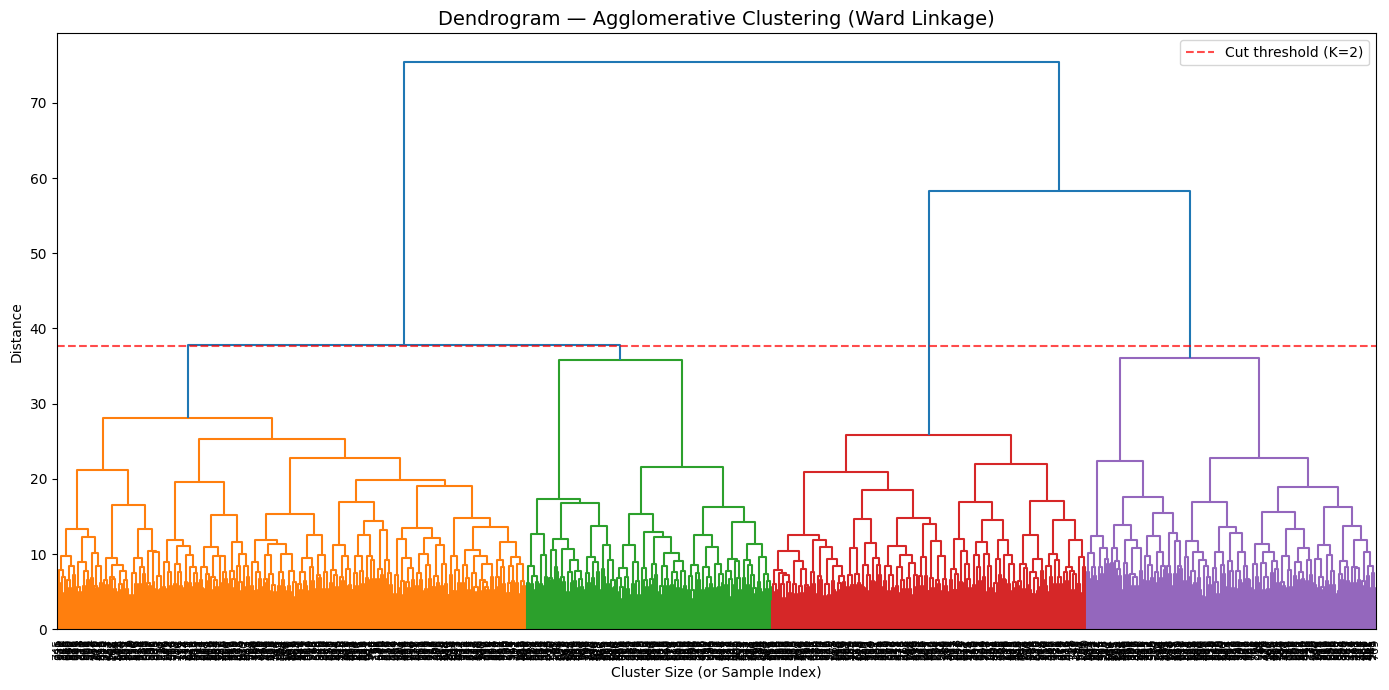

In [42]:
Z = scipy_linkage(X, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(Z,
           truncate_mode='lastp',
           p=3000, 
           leaf_rotation=90,
           leaf_font_size=8,
           show_contracted=True,
           color_threshold=Z[-1, 2] * 0.5)
plt.title("Dendrogram — Agglomerative Clustering (Ward Linkage)", fontsize=14)
plt.xlabel("Cluster Size (or Sample Index)")
plt.ylabel("Distance")
plt.axhline(y=Z[-1, 2] * 0.5, color='r', linestyle='--', alpha=0.7, label='Cut threshold (K=2)')
plt.legend()
plt.tight_layout()
plt.show()

## t-SNE Visualization of Agglomerative Clustering

Running t-SNE (perplexity=30, max_iter=1000)... this may take a moment.


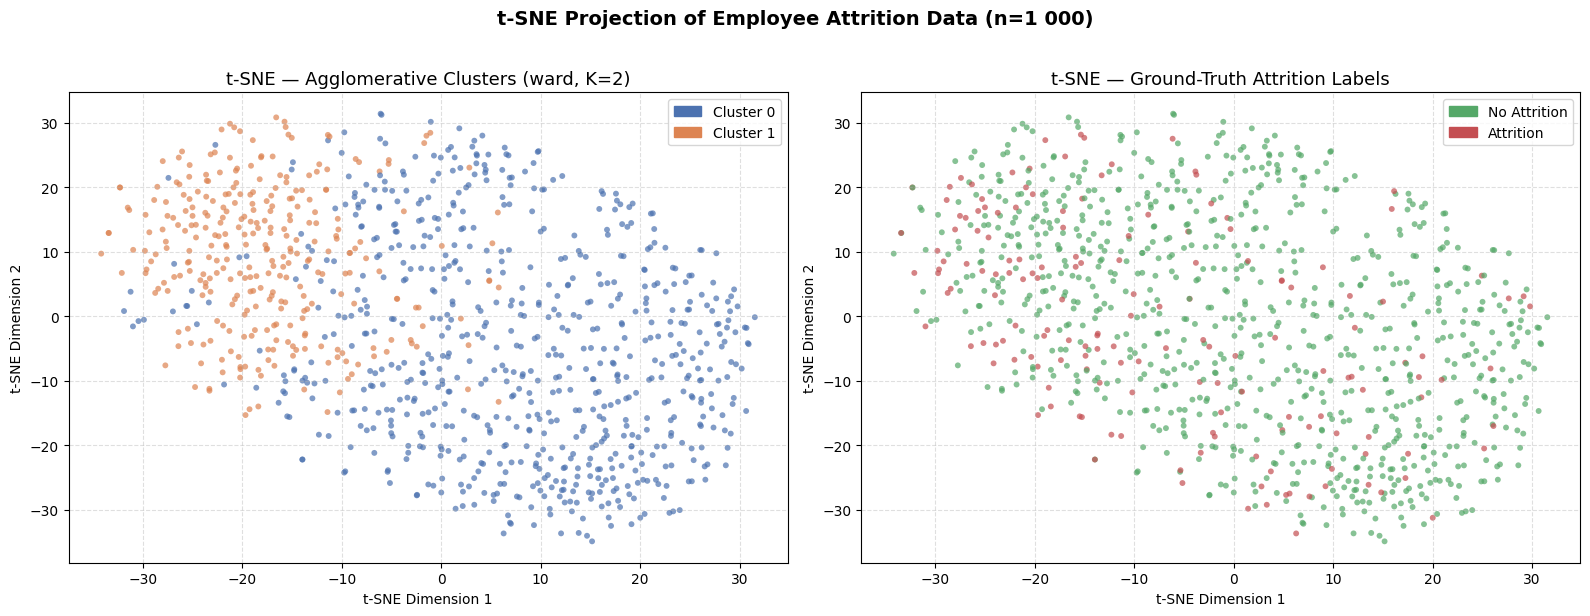


Note: t-SNE is a 2-D visualisation tool — it does not change the 
clustering results, only helps us see the cluster structure visually.


In [43]:
print("Running t-SNE (perplexity=30, max_iter=1000)... this may take a moment.")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X)

cluster_colors  = np.array(["#4C72B0", "#DD8452"]) 
true_colors     = np.array(["#55A868", "#C44E52"])   

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Aggromerative Clusters
ax = axes[0]
scatter_c = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=[cluster_colors[l] for l in labels],
    s=18, alpha=0.7, edgecolors="none"
)
patch0 = mpatches.Patch(color=cluster_colors[0], label="Cluster 0")
patch1 = mpatches.Patch(color=cluster_colors[1], label="Cluster 1")
ax.legend(handles=[patch0, patch1], loc="best", fontsize=10)
ax.set_title("t-SNE — Agglomerative Clusters (ward, K=2)", fontsize=13)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.grid(True, linestyle="--", alpha=0.4)

# Ground truth
ax = axes[1]
scatter_t = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=[true_colors[y] for y in y_true],
    s=18, alpha=0.7, edgecolors="none"
)
patch_no  = mpatches.Patch(color=true_colors[0], label="No Attrition")
patch_yes = mpatches.Patch(color=true_colors[1], label="Attrition")
ax.legend(handles=[patch_no, patch_yes], loc="best", fontsize=10)
ax.set_title("t-SNE — Ground-Truth Attrition Labels", fontsize=13)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("t-SNE Projection of Employee Attrition Data (n=1 000)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nNote: t-SNE is a 2-D visualisation tool — it does not change the",
      "\nclustering results, only helps us see the cluster structure visually.")
